[Device] cpu
  PINN v5 — temp=depth fix + real rainfall

──────────────────────────────────────────────────────────────
[CSV] /content/label_109_EMA_optimized_PINN.csv
──────────────────────────────────────────────────────────────
  Rows:26636  Cols:['timestamp', 'devid', 'soil_', 'temp', 'temp_', 'humi', 'geo', 'soil', 'rain']  sep=','
  Time : '%m/%d/%Y %H:%M'  [0.0, 443.9]h (18.5 days)
  T_MAX → 444h
  Geo  : constant → x assigned to mid-domain (10.0m)
  Geo  : x = 10.0 – 10.0m
  Depth: 'temp'=7m from surface → z_base=3.0m → Clay layer
  Rain : peak=45.68mm/hr  mean=0.383mm/hr  nonzero=2660/26636 rows
  Soil : θ=[0.100, 0.460]  mean=0.339  std=0.0563  clipped_lo=30  clipped_hi=1130
  t_n  : [0.0000, 0.9998]  ✓
  Built: rain=26636  θ_obs=26636  IC=1331

  ┌─────────────────────────────────────────────────────┐
  │ Rows         : 26636                                │
  │ Time         : 0.0 – 443.9 h  (18.5 days)            │
  │ x (m)        : 10.0 – 10.0 m  (single sensor)         │

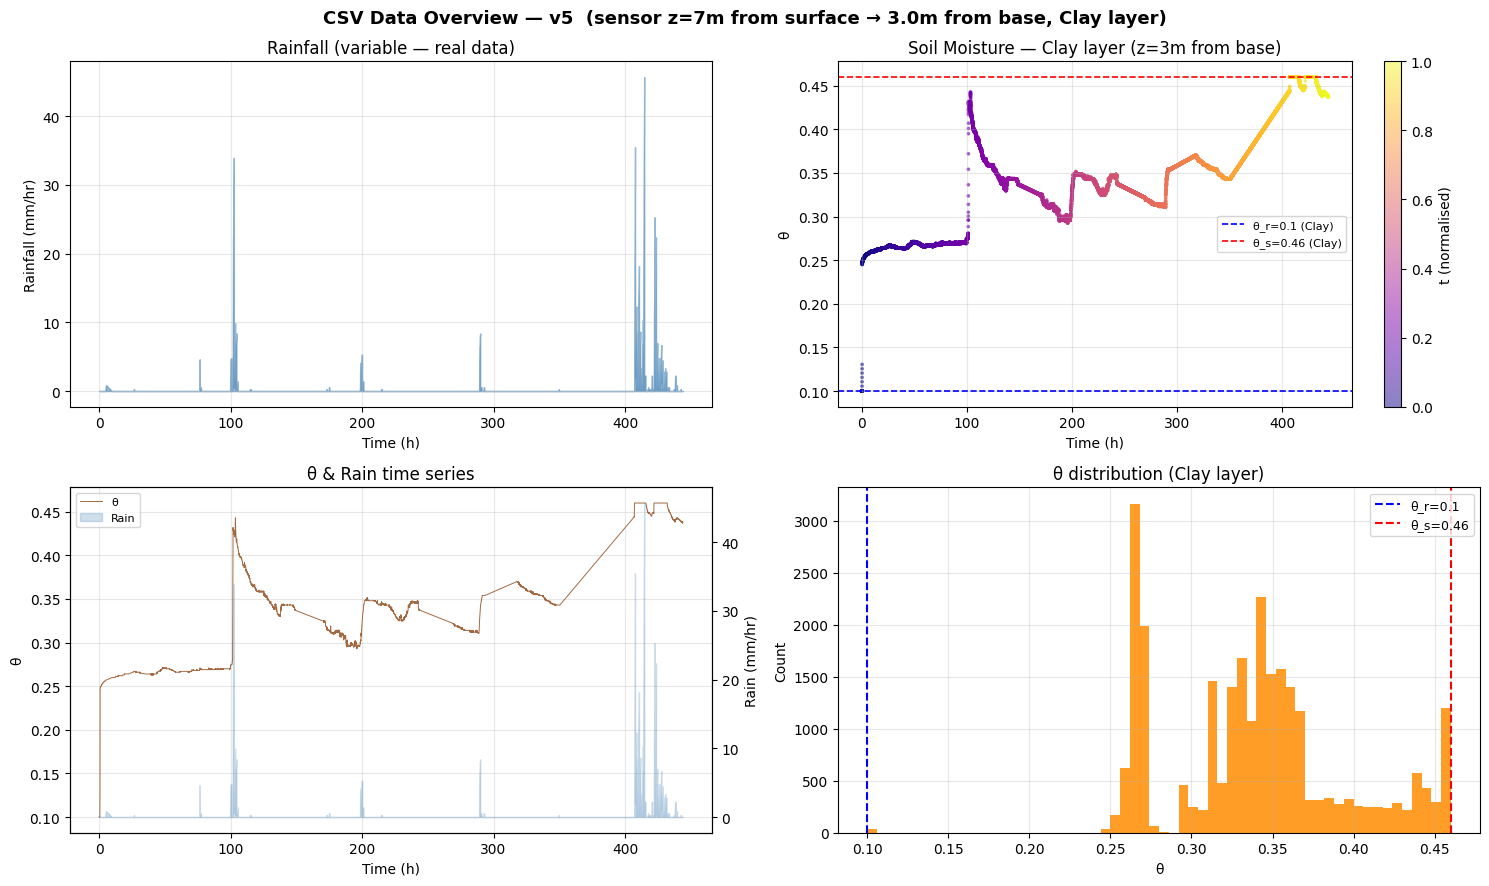


  Domain  : 20.0×10.0m  over 444h (18.5 days)
  Sensor  : z=3.0m from base (Clay layer)
  Slope   : 30.0°   Device: cpu
  [Data]  CSV — 26636 obs  T_MAX=444h
  [z_obs] 3.00–3.00m  (sensor at 3.0m from base)
  [theta] 0.100–0.460  mean=0.339  std=0.0563
  [rain]  peak=45.68mm/hr  nonzero=2660 timesteps
  [R²]    Before training : -1.1432
  [Phase] 1 = data+IC warmup (ep 1–500)
  [Phase] 2 = all losses    (ep 501–10000)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────
    Ep  Ph      Total       Data      Cons     Hydro        IC        BC        R²
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
     1 Ph1   4.949e+01   4.804e-02  1.489e+00  0.000e+00  1.321e+02  0.000e+00    -1.1101
   250 Ph1   7.794e+00   9.386e-03  1.393e+00  0.000e+00  1.195e+00  0.000e+00     0.6172
   500 Ph1   3.544e+00   9.110e-03  5.428e-01  0.000e+00  1.249e+00  0.000e+00     0.6317
 

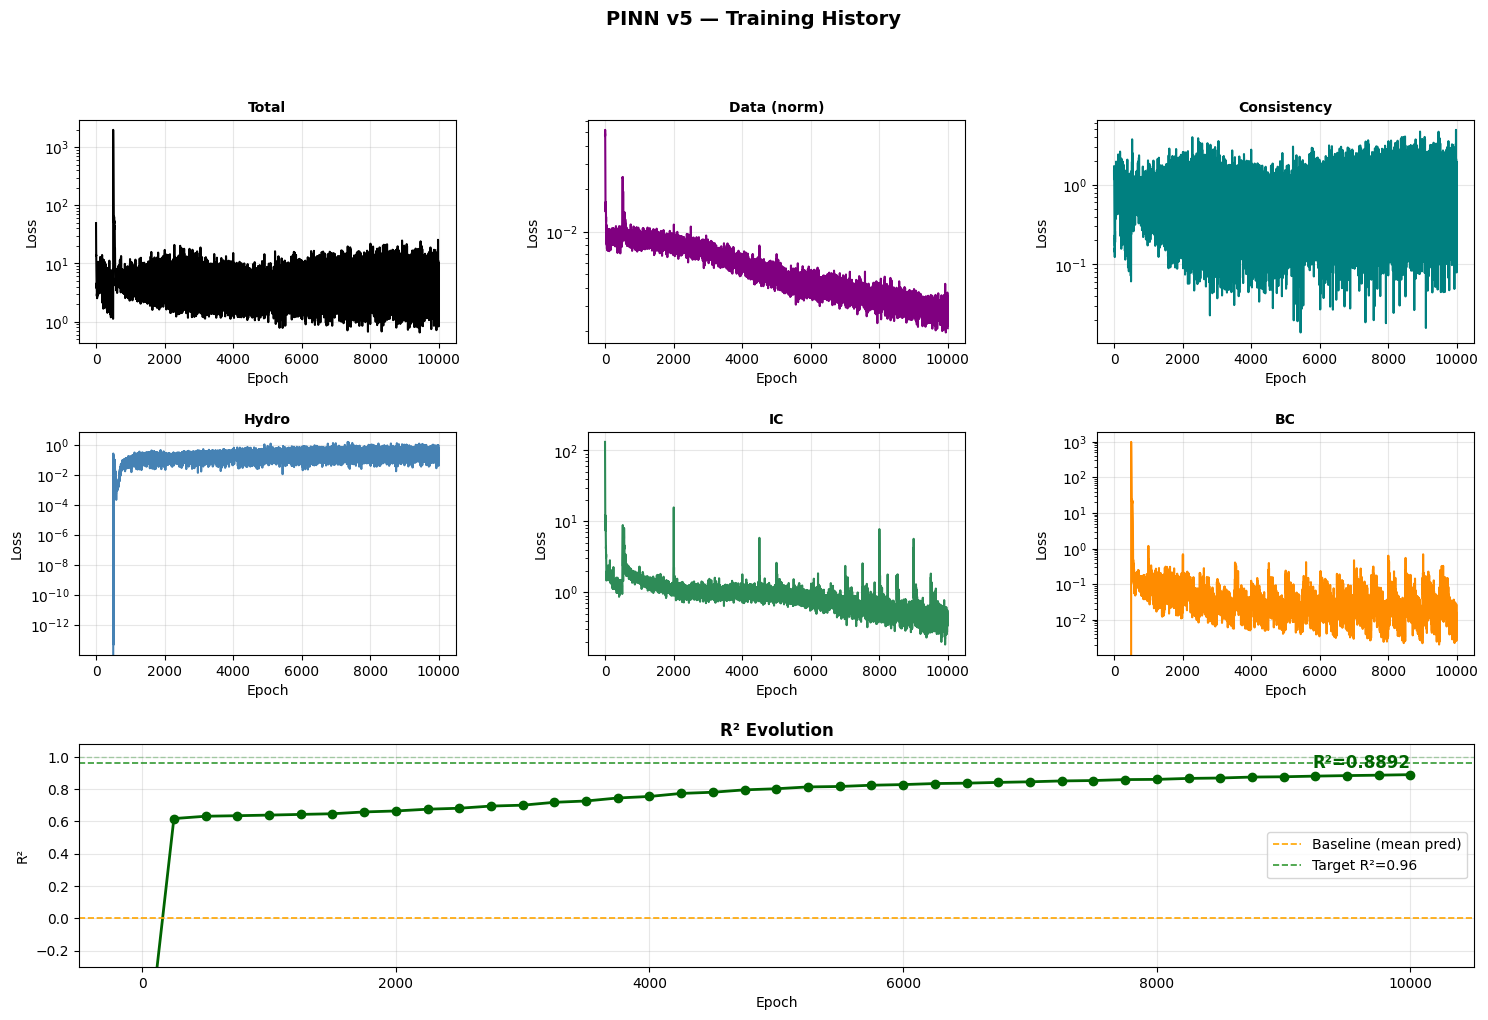

[Plot] Parity → parity_v5.png  R²=0.8892


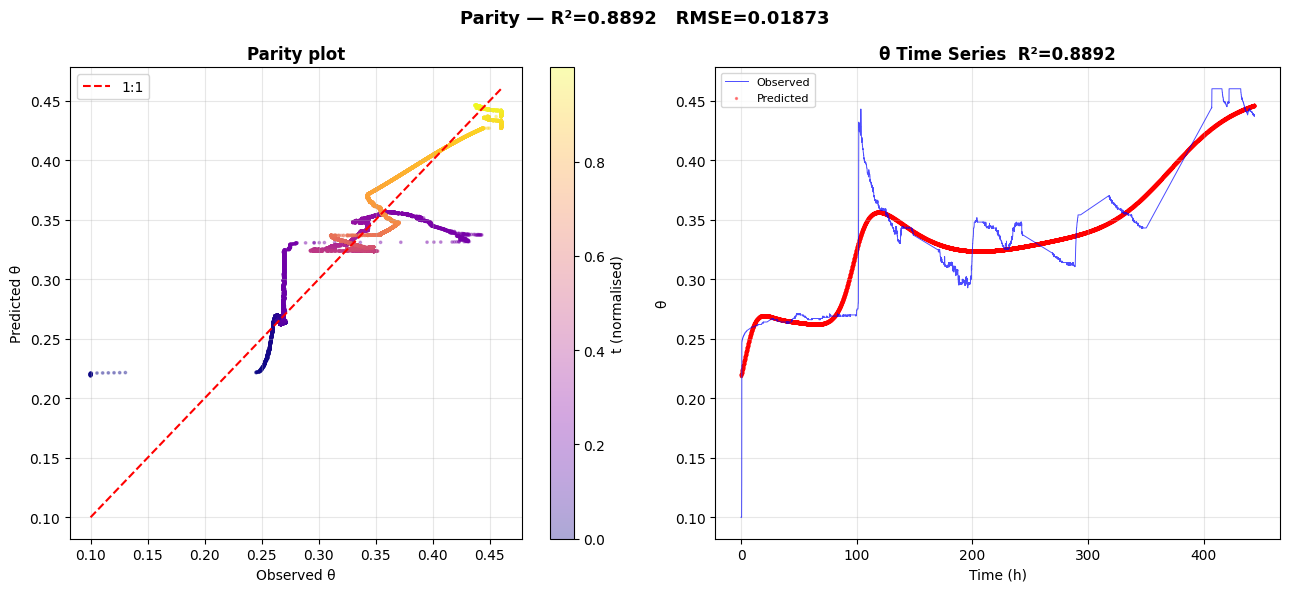

[Plot] Fields → fields_v5.png


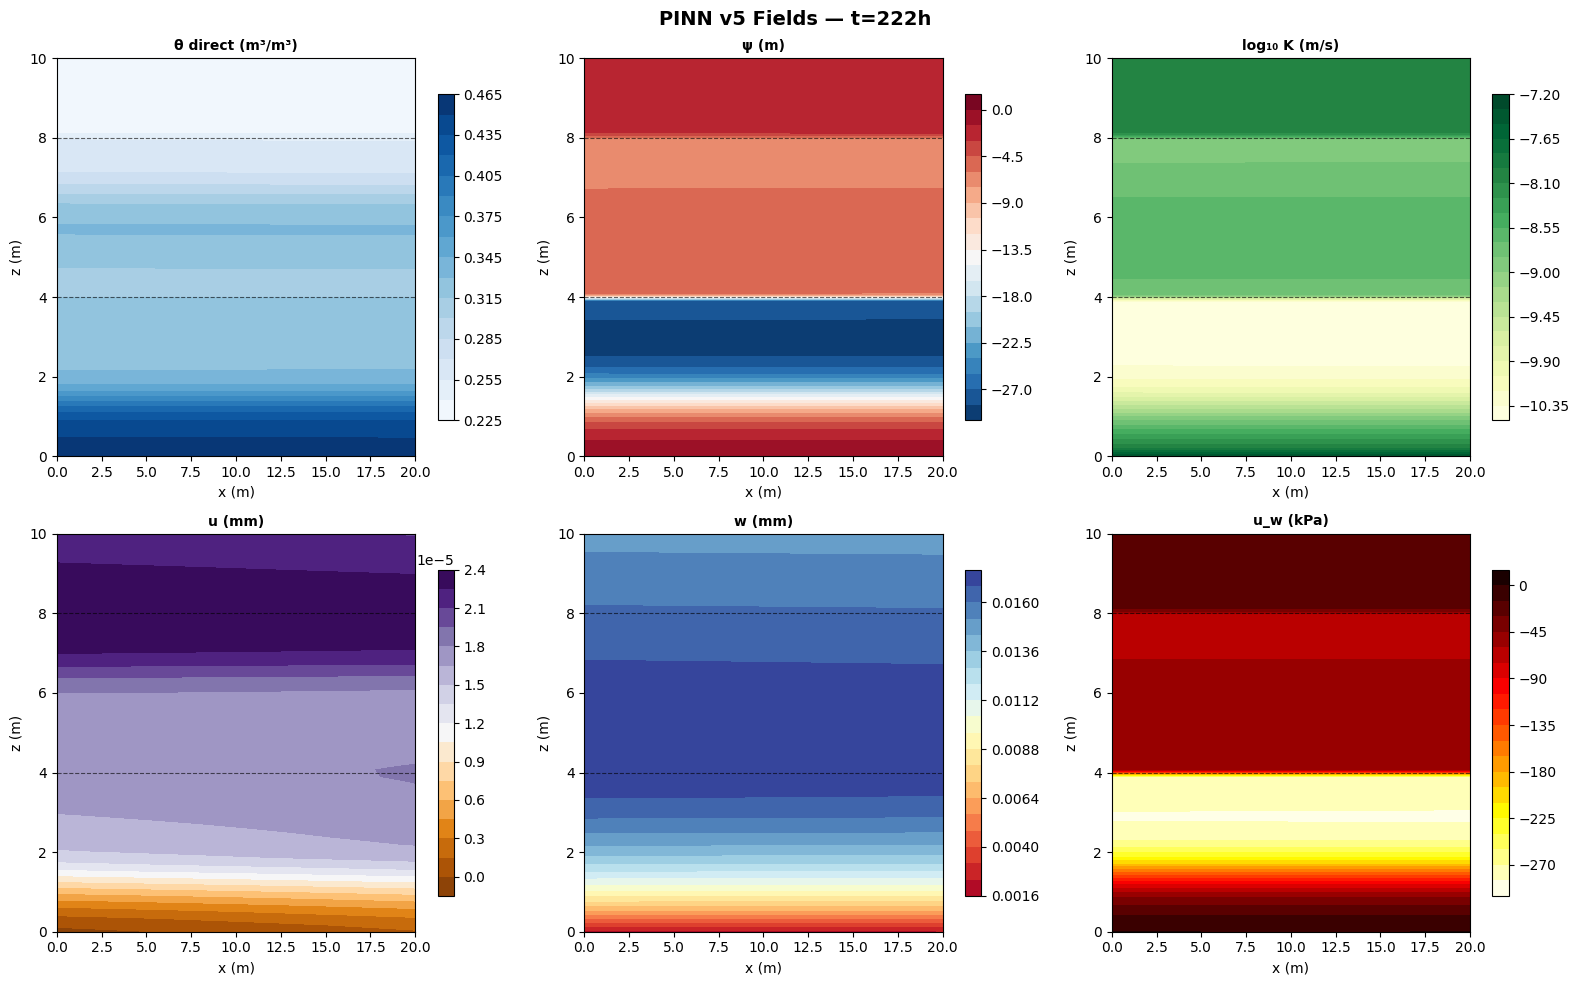

[Plot] FoS → fos_v5.png


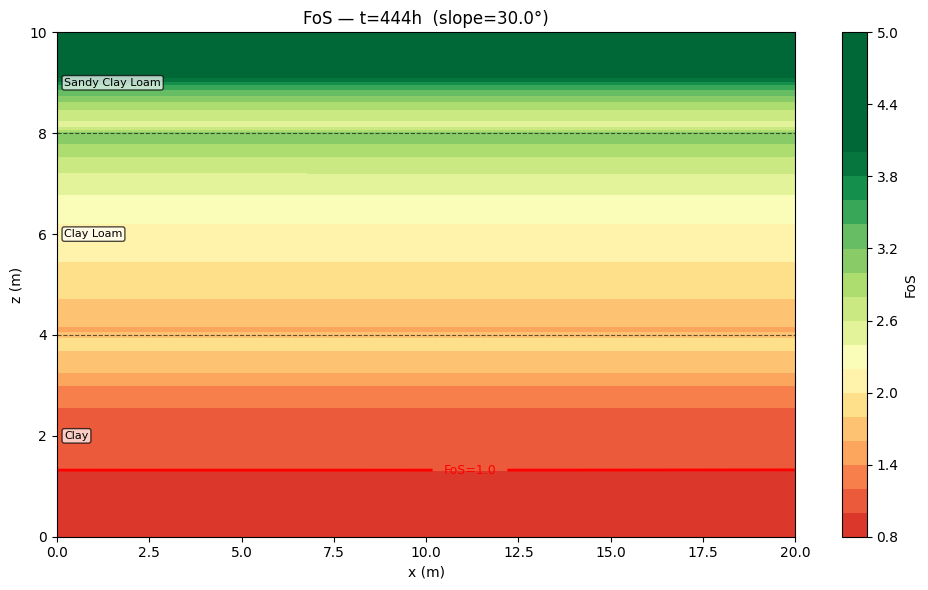

[Plot] FoS evolution → fos_evo_v5.png


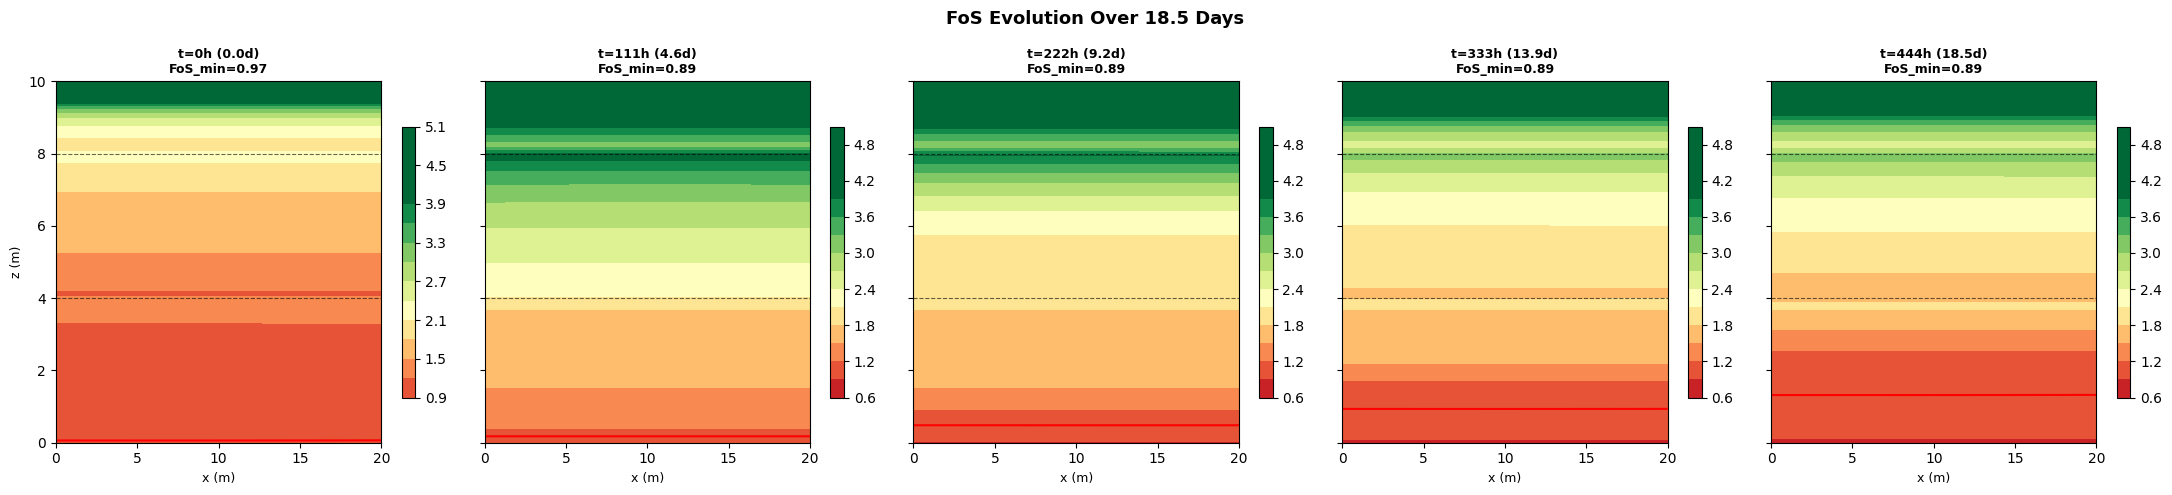


  v5 Results Summary
  Sensor config : z=7m from surface → z=3m from base (Clay)
  Time span     : 444h = 18.5 days
  R² (θ direct) : 0.8892
  RMSE          : 0.01873
  Min  FoS      : 0.891
  Mean FoS      : 2.402
  FoS < 1.0     : 13.3% of domain
  ⚠  FAILURE ZONE


In [1]:
"""
============================================================
PINN v5 — Updated for Corrected CSV (temp = fixed depth)
============================================================

CHANGES FROM v4
─────────────────────────────────────────────────────────────

[V5-1] temp COLUMN IS NOW SENSOR DEPTH (fixed at 7m from surface)
  The user has fixed the CSV so 'temp' now holds the sensor
  installation depth in metres (constant = 7). This is depth
  measured FROM THE SURFACE downward (DEPTH_POS_DOWN = True).

  Sensor depth from surface = 7m
  → z from base = Z_MAX - 7 = 10 - 7 = 3.0m
  → This places the sensor in the CLAY layer (z ∈ [0, 4]m)
       theta_r = 0.100,  theta_s = 0.460
       alpha   = 0.15,   n       = 1.25
       Ks      = 5.56e-8 m/s

  The v4 code assigned z=6m (Clay Loam) as a fallback because
  there was no depth column. Now we read it directly from 'temp'.

[V5-2] rain COLUMN NOW HAS REAL VARIABLE DATA
  In the original CSV, rain was constant at 7 mm/hr.
  The user's fixed CSV has real rainfall: 0–45.68 mm/hr,
  with 2660/26636 nonzero rows (events spread over 18.5 days).
  The CSV rainfall boundary condition will now carry real signal.

[V5-3] SOIL THETA CLIPPING UPDATED FOR CLAY LAYER
  Previously clipped to [theta_r_min=0.065, theta_s_max=0.460].
  Sensor is now confirmed in Clay layer:
       theta_r = 0.100,  theta_s = 0.460
  95.6% of obs already in [0.10, 0.46]. Clip to [0.10, 0.46].
  The 0.1% below theta_r (very dry early readings) → set to 0.10.
  The 4.2% above theta_s (super-saturated events)  → set to 0.46.

[V5-4] COL_TEMP RESTORED AS DEPTH COLUMN (no longer SINGLE_DEPTH_SENSOR)
  SINGLE_DEPTH_SENSOR = False
  COL_DEPTH = "temp"   (constant=7, depth from surface in metres)
  DEPTH_POS_DOWN = True → z_from_base = Z_MAX - 7 = 3.0m

[V5-5] temp_ COLUMN (actual air temperature) — IGNORED
  temp_ contains air temperature 18–38°C. Not used by PINN.
  Documented here so future multi-sensor extensions can add it
  as an auxiliary input if desired.

All other v4 fixes retained:
  - T_MAX auto-expands to 444h [BUG-2]
  - geo constant → x = X_MAX/2 [BUG-3]
  - Timestamp format %m/%d/%Y %H:%M first [BUG-5]
  - CSV loaded before train() [BUG-7]
  - Two-phase training, direct theta head, consistency loss
============================================================
"""

import os
import warnings
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.autograd import grad as autograd_grad

warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Device] {device}")

# ── Domain ────────────────────────────────────────────────────
X_MAX       = 20.0
Z_MAX       = 10.0
T_MAX       = 24.0        # Auto-expands to 444h from CSV
SLOPE_ANGLE = 30.0
RHO_W       = 1000.0
G_ACC       = 9.81
E_REF       = 1.0e6

# ── CSV Column Mappings ── [V5-4] ─────────────────────────────
CSV_FILE    = "/content/label_109_EMA_optimized_PINN.csv"

COL_TIME      = "timestamp"   # "11/2/2025 4:44" format
COL_GEO       = "geo"         # horizontal position (constant=10)
COL_DEPTH     = "temp"        # [V5-4] sensor depth from surface (m), constant=7
COL_RAINFALL  = "rain"        # [V5-2] rainfall mm/hr, now variable 0–45.68
COL_SOIL      = "soil"        # volumetric water content (0–1)
RAINFALL_UNIT = "mm/hr"

# [V5-4] temp column is depth, DEPTH_POS_DOWN=True → z_base = Z_MAX - depth
SINGLE_DEPTH_SENSOR = False   # We now have a real depth column
DEPTH_POS_DOWN      = True    # temp=7 means 7m from surface → z_base=3m

GEO_IS_LATLON = False

TIMESTAMP_FORMATS = [
    "%m/%d/%Y %H:%M",          # Matches "11/2/2025 4:44" — FIRST priority
    "%d/%m/%Y %H:%M", "%d/%m/%Y %H:%M:%S", "%d-%m-%Y %H:%M",
    "%Y-%m-%d %H:%M", "%Y-%m-%d %H:%M:%S", "%m/%d/%Y %H:%M:%S",
]

# ── Soil layers ───────────────────────────────────────────────
SOIL = {
    1: dict(z_lo=8.0,  z_hi=10.0,
            theta_r=0.065, theta_s=0.410, alpha=0.75, n=1.89,
            Ks=1.22e-6,  E=5.0e6,  nu=0.30, rho_b=1600.0,
            c_prime=10.0e3, phi_prime=30.0),
    2: dict(z_lo=4.0,  z_hi=8.0,
            theta_r=0.078, theta_s=0.430, alpha=0.36, n=1.56,
            Ks=2.89e-7,  E=8.0e6,  nu=0.35, rho_b=1700.0,
            c_prime=15.0e3, phi_prime=25.0),
    3: dict(z_lo=0.0,  z_hi=4.0,
            theta_r=0.100, theta_s=0.460, alpha=0.15, n=1.25,
            Ks=5.56e-8,  E=15.0e6, nu=0.40, rho_b=1800.0,
            c_prime=20.0e3, phi_prime=20.0),
}

# [V5-3] Clip bounds for the confirmed Clay sensor layer
THETA_CLIP_LO = SOIL[3]["theta_r"]   # 0.100
THETA_CLIP_HI = SOIL[3]["theta_s"]   # 0.460

def _lp(z_norm, key):
    z_m = z_norm * Z_MAX
    v1 = float(SOIL[1][key]); v2 = float(SOIL[2][key]); v3 = float(SOIL[3][key])
    return torch.where(z_m >= 8.0, v1 * torch.ones_like(z_m),
           torch.where(z_m >= 4.0, v2 * torch.ones_like(z_m),
                                   v3 * torch.ones_like(z_m)))

# ── Van Genuchten ─────────────────────────────────────────────
def vg_Se(psi, z):
    alpha = _lp(z, "alpha"); n = _lp(z, "n"); m = 1.0 - 1.0 / n
    arg = torch.clamp(alpha * torch.abs(psi), min=0.0)
    Se = 1.0 / (1.0 + arg.pow(n)).pow(m)
    Se = torch.where(psi >= 0.0, torch.ones_like(psi), Se)
    return torch.clamp(Se, min=1e-6, max=1.0 - 1e-6)

def vg_theta(psi, z):
    return _lp(z, "theta_r") + vg_Se(psi, z) * (_lp(z, "theta_s") - _lp(z, "theta_r"))

def vg_K(psi, z):
    Ks = _lp(z, "Ks"); n = _lp(z, "n"); m = 1.0 - 1.0 / n
    Se = vg_Se(psi, z)
    Se_c = torch.clamp(Se, min=1e-6, max=1.0 - 1e-6)
    inner = torch.clamp(1.0 - Se_c.pow(1.0 / m), min=0.0)
    K = Ks * Se.pow(0.5) * (1.0 - inner.pow(m)).pow(2.0)
    return torch.clamp(K, min=1e-15, max=1e-2)

def dtheta_dpsi(psi, z):
    alpha = _lp(z, "alpha"); n = _lp(z, "n"); m = 1.0 - 1.0 / n
    dts = _lp(z, "theta_s") - _lp(z, "theta_r")
    arg = torch.clamp(alpha * torch.abs(psi), min=0.0)
    denom = 1.0 + arg.pow(n)
    C = dts * m * n * alpha * arg.pow(n - 1.0) / denom.pow(m + 1.0)
    C = torch.where(psi >= 0.0, torch.zeros_like(psi), C)
    return torch.clamp(C, min=0.0, max=10.0)

def inv_vg_psi(theta, z):
    """Analytical inverse VG: θ → ψ (always ≤ 0), clamped to [-500, 0]."""
    alpha = _lp(z, "alpha"); n = _lp(z, "n"); m = 1.0 - 1.0 / n
    theta_r = _lp(z, "theta_r"); theta_s = _lp(z, "theta_s")
    Se = torch.clamp((theta - theta_r) / (theta_s - theta_r), min=1e-6, max=1.0 - 1e-6)
    inner = torch.clamp(Se.pow(-1.0 / m) - 1.0, min=0.0)
    psi = -(1.0 / alpha) * inner.pow(1.0 / n)
    return torch.clamp(psi, min=-500.0, max=0.0)

# ── Elasticity ────────────────────────────────────────────────
def lame(z):
    E = _lp(z, "E"); nu = _lp(z, "nu")
    lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
    mu  = E / (2.0 * (1.0 + nu))
    return lam, mu

def _grad(y, v):
    return autograd_grad(y, v, grad_outputs=torch.ones_like(y),
                         create_graph=True, retain_graph=True)[0]

def stress_2d(u, w, x, z):
    eps_xx = _grad(u, x); eps_zz = _grad(w, z)
    gamma  = _grad(u, z) + _grad(w, x)
    lam_t, mu_t = lame(z)
    dil = eps_xx + eps_zz
    sxx = (lam_t * dil + 2.0 * mu_t * eps_xx) / E_REF
    szz = (lam_t * dil + 2.0 * mu_t * eps_zz) / E_REF
    txz = (mu_t * gamma)                       / E_REF
    return sxx, szz, txz

# ── Neural Network ────────────────────────────────────────────
class PINN(nn.Module):
    """
    4 outputs:
      psi         — pressure head (m), drives Richards PDE & FoS
      u, w        — displacements (m), drive momentum PDE
      theta_direct— volumetric water content ∈ (θ_r, θ_s) per layer,
                    trained directly against observations
    """
    def __init__(self, hidden=6, width=128):
        super().__init__()
        layers = [nn.Linear(3, width), nn.Tanh()]
        for _ in range(hidden - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        self.trunk      = nn.Sequential(*layers)
        self.head_psi   = nn.Linear(width, 1)
        self.head_disp  = nn.Linear(width, 2)
        self.head_theta = nn.Linear(width, 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)

    def forward(self, x, z, t):
        feat = self.trunk(torch.cat([x, z, t], dim=1))

        # Layer-aware psi: deeper Clay needs wider range (up to -50m)
        z_m = z * Z_MAX
        raw_psi = self.head_psi(feat)
        scale = torch.where(z_m >= 8.0,  3.0 * torch.ones_like(z_m),
                torch.where(z_m >= 4.0,  7.0 * torch.ones_like(z_m),
                                        25.0 * torch.ones_like(z_m)))
        shift = torch.where(z_m >= 8.0, -1.5 * torch.ones_like(z_m),
                torch.where(z_m >= 4.0, -4.0 * torch.ones_like(z_m),
                                       -20.0 * torch.ones_like(z_m)))
        psi = scale * torch.tanh(raw_psi) + shift

        raw_d = self.head_disp(feat)
        u = raw_d[:, 0:1] * 1e-3
        w = raw_d[:, 1:2] * 1e-3

        # Direct theta: sigmoid scaled to (theta_r, theta_s) per layer
        raw_th  = self.head_theta(feat)
        theta_r = _lp(z, "theta_r")
        theta_s = _lp(z, "theta_s")
        theta_d = theta_r + (theta_s - theta_r) * torch.sigmoid(raw_th)

        return psi, u, w, theta_d

# ── Collocation points ────────────────────────────────────────
def sample_pts(n_int, n_bc, n_ic):
    def rn(n): return torch.rand(n, 1, device=device)
    def ze(n): return torch.zeros(n, 1, device=device)
    def on(n): return torch.ones(n, 1, device=device)
    def rq(*ts): return tuple(t.requires_grad_(True) for t in ts)
    return dict(
        int=rq(rn(n_int), rn(n_int), rn(n_int)),
        ic =rq(rn(n_ic),  rn(n_ic),  ze(n_ic)),
        top=rq(rn(n_bc),  on(n_bc),  rn(n_bc)),
        bot=rq(rn(n_bc),  ze(n_bc),  rn(n_bc)),
        lft=rq(ze(n_bc),  rn(n_bc),  rn(n_bc)),
        rgt=rq(on(n_bc),  rn(n_bc),  rn(n_bc)),
    )

def psi_initial(z_norm):
    return -(Z_MAX - z_norm * Z_MAX) * 0.4

_q_rain_fn = None

def q_rain_fallback(t_norm):
    """Fallback: small constant drizzle scaled to T_MAX."""
    return 1.94e-6 * torch.ones_like(t_norm)   # ≈ 7 mm/hr in m/s

def get_q_rain():
    return _q_rain_fn if _q_rain_fn is not None else q_rain_fallback

# ── Utilities ─────────────────────────────────────────────────
def safe_mean_sq(residual, name=""):
    val = torch.mean(residual ** 2)
    if not torch.isfinite(val):
        print(f"  ⚠  NaN/Inf in '{name}' — skipping")
        return torch.tensor(0.0, device=residual.device, requires_grad=True)
    return val

def compute_r2(model, x_obs, z_obs, t_obs, theta_obs):
    with torch.no_grad():
        _, _, _, theta_d = model(x_obs, z_obs, t_obs)
        ss_res = torch.sum((theta_d - theta_obs) ** 2)
        ss_tot = torch.sum((theta_obs - theta_obs.mean()) ** 2)
        if ss_tot < 1e-12: return float("nan")
        return (1.0 - ss_res / ss_tot).item()

# ── PDE Losses ────────────────────────────────────────────────
def loss_richards(model, x, z, t):
    psi, _, _, _ = model(x, z, t)
    K = vg_K(psi, z); C = dtheta_dpsi(psi, z)
    Kx = K * _grad(psi, x)
    Kz = K * (_grad(psi, z) + 1.0)
    res = C * _grad(psi, t) - _grad(Kx, x) - _grad(Kz, z)
    return safe_mean_sq(res, "richards")

def loss_ic(model, x, z, t):
    psi, u, w, _ = model(x, z, t)
    return (safe_mean_sq(psi - psi_initial(z), "ic_psi")
          + safe_mean_sq(u, "ic_u")
          + safe_mean_sq(w, "ic_w"))

def loss_bc_top(model, x, z, t):
    psi, u, w, _ = model(x, z, t)
    K      = vg_K(psi, z)
    q_pred = -K * (_grad(psi, z) + 1.0)
    l_flux = safe_mean_sq(q_pred - get_q_rain()(t), "bc_top_flux")
    _, szz, txz = stress_2d(u, w, x, z)
    return l_flux + 0.05 * (safe_mean_sq(szz, "szz") + safe_mean_sq(txz, "txz"))

def loss_bc_bot(model, x, z, t):
    psi, u, w, _ = model(x, z, t)
    return (safe_mean_sq(psi, "bc_bot_psi")
          + safe_mean_sq(u,   "bc_bot_u")
          + safe_mean_sq(w,   "bc_bot_w"))

def loss_bc_sides(model, xl, zl, tl, xr, zr, tr):
    pl, _, _, _ = model(xl, zl, tl)
    pr, _, _, _ = model(xr, zr, tr)
    return (safe_mean_sq(_grad(pl, xl), "side_l")
          + safe_mean_sq(_grad(pr, xr), "side_r"))

def loss_mech(model, x, z, t):
    _, u, w, _ = model(x, z, t)
    sxx, szz, txz = stress_2d(u, w, x, z)
    body = _lp(z, "rho_b") * G_ACC / E_REF
    return (safe_mean_sq(_grad(sxx, x) + _grad(txz, z),        "mech_x")
          + safe_mean_sq(_grad(txz, x) + _grad(szz, z) + body, "mech_z"))

def loss_data(model, x_obs, z_obs, t_obs, theta_obs):
    """Normalised data loss via theta_direct head."""
    _, _, _, theta_d = model(x_obs, z_obs, t_obs)
    dts = _lp(z_obs, "theta_s") - _lp(z_obs, "theta_r")
    normalised_res = (theta_d - theta_obs) / (dts + 1e-6)
    return safe_mean_sq(normalised_res, "data_theta_norm")

def loss_consistency(model, x, z, t):
    """psi head ↔ theta_direct via inverse VG — keeps psi physically grounded."""
    psi, _, _, theta_d = model(x, z, t)
    psi_target = inv_vg_psi(theta_d.detach(), z)
    psi_scale = torch.where(z * Z_MAX >= 8.0,  3.0 * torch.ones_like(z),
                torch.where(z * Z_MAX >= 4.0, 10.0 * torch.ones_like(z),
                                              50.0 * torch.ones_like(z)))
    res = (psi - psi_target) / (psi_scale + 1e-6)
    return safe_mean_sq(res, "consistency")

def synthetic_sensors(n=300):
    xo = torch.rand(n, 1, device=device)
    zo = torch.rand(n, 1, device=device)
    to = torch.rand(n, 1, device=device)
    tr = _lp(zo, "theta_r"); ts = _lp(zo, "theta_s")
    t_h = to * T_MAX
    sat = 0.3 + 0.5 * torch.exp(-0.5 * ((t_h - T_MAX * 0.375) / (T_MAX * 0.1)) ** 2)
    th = torch.clamp(tr + sat * (ts - tr) + 0.005 * torch.randn_like(tr), min=tr, max=ts)
    return xo, zo, to, th

# ── Two-Phase Training ────────────────────────────────────────
def train(warmup_epochs=500, total_epochs=10000, lr=2e-4,
          n_int=100, n_bc=150, n_ic=200,
          lam_h=1.0, lam_m=0.001, lam_ic=0.5,
          lam_bc=2.0, lam_data=50.0, lam_cons=5.0,
          csv_loader=None, print_every=250):

    global _q_rain_fn
    model = PINN(hidden=6, width=128).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                opt, T_0=500, T_mult=1, eta_min=5e-7)

    use_csv = csv_loader is not None and getattr(csv_loader, "_loaded", False)
    if use_csv:
        csv_loader.to(device)
        xo  = csv_loader.x_obs_norm
        zo  = csv_loader.z_obs_norm
        to_ = csv_loader.t_obs_norm
        tho = csv_loader.theta_obs
        _q_rain_fn = csv_loader.make_q_rain_fn()
        print(f"  [Data]  CSV — {len(tho)} obs  T_MAX={T_MAX:.0f}h")
        print(f"  [z_obs] {(zo*Z_MAX).min().item():.2f}–{(zo*Z_MAX).max().item():.2f}m  "
              f"(sensor at {Z_MAX - csv_loader.depth_val:.1f}m from base)")
        print(f"  [theta] {tho.min().item():.3f}–{tho.max().item():.3f}  "
              f"mean={tho.mean().item():.3f}  std={tho.std().item():.4f}")
        print(f"  [rain]  peak={csv_loader.q_rain_ms.max().item()*3.6e6:.2f}mm/hr  "
              f"nonzero={( csv_loader.q_rain_ms > 0).sum().item()} timesteps")
    else:
        xo, zo, to_, tho = synthetic_sensors(300)
        _q_rain_fn = None
        print("  [Data]  Synthetic sensors (no CSV)")

    r2_init = compute_r2(model, xo, zo, to_, tho)
    print(f"  [R²]    Before training : {r2_init:.4f}")
    print(f"  [Phase] 1 = data+IC warmup (ep 1–{warmup_epochs})")
    print(f"  [Phase] 2 = all losses    (ep {warmup_epochs+1}–{total_epochs})")

    hist = defaultdict(list)
    N = len(tho)
    bar = "─" * 110
    print(f"\n{bar}")
    print(f"{'Ep':>6} {'Ph':>3} {'Total':>10} {'Data':>10} "
          f"{'Cons':>9} {'Hydro':>9} {'IC':>9} {'BC':>9} {'R²':>9}")
    print(bar)

    nan_count = 0
    for ep in range(1, total_epochs + 1):
        opt.zero_grad()
        phase = 1 if ep <= warmup_epochs else 2

        p = sample_pts(n_int, n_bc, n_ic)
        xi, zi, ti = p["int"]
        xc, zc, tc = p["ic"]
        xt, zt, tt = p["top"]
        xb, zb, tb = p["bot"]
        xl, zl, tl = p["lft"]
        xr, zr, tr = p["rgt"]

        # Mini-batch shuffle
        idx  = torch.randperm(N, device=device)[:min(N, 512)]
        xob  = xo[idx].requires_grad_(False)
        zob  = zo[idx].requires_grad_(False)
        tob  = to_[idx].requires_grad_(False)
        thob = tho[idx]

        lD    = loss_data(model, xob, zob, tob, thob)
        lCons = loss_consistency(model, xi, zi, ti)
        lI    = loss_ic(model, xc, zc, tc)

        if phase == 1:
            # Warmup: data + consistency + light IC only
            total = lam_data * lD + lam_cons * lCons + 0.3 * lI
            lH = torch.tensor(0.0); lB = torch.tensor(0.0)
        else:
            lH = loss_richards(model, xi, zi, ti)
            lB = (loss_bc_top  (model, xt, zt, tt)
                + loss_bc_bot  (model, xb, zb, tb)
                + loss_bc_sides(model, xl, zl, tl, xr, zr, tr))
            lM = loss_mech(model, xi, zi, ti)
            total = (lam_data * lD + lam_cons * lCons
                   + lam_ic * lI   + lam_bc * lB
                   + lam_h * lH    + lam_m * lM)

        if not torch.isfinite(total):
            nan_count += 1
            print(f"  ⚠  Ep {ep}: NaN total")
            if nan_count >= 5: print("  ✗  Stopping."); break
            sched.step(); continue

        nan_count = 0
        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step(); sched.step()

        for k, v in [("total", total.item()), ("D", lD.item()),
                     ("Cons", lCons.item()),
                     ("H", lH if isinstance(lH, float) else lH.item()),
                     ("I", lI.item()),
                     ("B", lB if isinstance(lB, float) else lB.item())]:
            hist[k].append(v)

        if ep % print_every == 0 or ep == 1:
            r2 = compute_r2(model, xo, zo, to_, tho)
            hist["r2"].append((ep, r2))
            lH_v = lH if isinstance(lH, float) else lH.item()
            lB_v = lB if isinstance(lB, float) else lB.item()
            print(f"{ep:>6d} Ph{phase}  {total.item():>10.3e}  {lD.item():>10.3e}  "
                  f"{lCons.item():>9.3e}  {lH_v:>9.3e}  {lI.item():>9.3e}  "
                  f"{lB_v:>9.3e}  {r2:>9.4f}")

    final_r2 = compute_r2(model, xo, zo, to_, tho)
    print(f"{bar}")
    print(f"✓  Final R² = {final_r2:.4f}")
    _print_r2_advice(final_r2)
    return model, hist

def _print_r2_advice(r2):
    if r2 >= 0.96:   print("  ✓  Excellent — target R² achieved!")
    elif r2 >= 0.85: print("  ✓  Good fit. Try lam_data=60 or more epochs.")
    elif r2 >= 0.60: print("  ⚠  Moderate. Raise lam_data to 60–80, epochs to 8000.")
    else:            print("  ✗  Poor fit. Run plot_parity() to diagnose.")

# ── Factor of Safety ──────────────────────────────────────────
def compute_fos(model, t_norm=1.0, n=50):
    a = SLOPE_ANGLE * np.pi / 180.0
    xv = torch.linspace(0, 1, n, device=device)
    zv = torch.linspace(0, 1, n, device=device)
    Xg, Zg = torch.meshgrid(xv, zv, indexing="ij")
    Xf, Zf = Xg.reshape(-1, 1), Zg.reshape(-1, 1)
    Tf = torch.full_like(Xf, t_norm)
    with torch.no_grad():
        psi, _, _, _ = model(Xf, Zf, Tf)
    z_m   = Zf * Z_MAX
    rho_b = _lp(Zf, "rho_b"); c_p = _lp(Zf, "c_prime")
    phi_p = _lp(Zf, "phi_prime") * np.pi / 180.0
    H     = Z_MAX - z_m
    u_w   = torch.clamp(RHO_W * G_ACC * psi, min=-1e5, max=1e5)
    sigma_n = torch.clamp(rho_b * G_ACC * H * (np.cos(a) ** 2) - u_w, min=0.0)
    tau   = rho_b * G_ACC * H * np.sin(a) * np.cos(a)
    tau_f = c_p + sigma_n * torch.tan(phi_p)
    fos   = tau_f / (torch.abs(tau) + 1e-6)
    return fos.reshape(n, n).cpu().numpy(), Xg.cpu().numpy() * X_MAX, Zg.cpu().numpy() * Z_MAX

# ── CSV Loader ────────────────────────────────────────────────
class CSVDataLoader:
    """
    v5 loader — handles the fixed CSV where:
      'temp'  = sensor depth from surface in metres (constant = 7)
      'rain'  = variable rainfall in mm/hr (0 – 45.68)
      'soil'  = volumetric water content (already 0–1)
      'geo'   = horizontal position (constant = 10, single sensor)
    """
    def __init__(self, filepath=None):
        self.filepath  = filepath
        self.df        = None
        self._loaded   = False
        self.depth_val = None      # stores raw depth value from 'temp' column
        for a in ["t_rain_h", "q_rain_ms", "x_obs_norm", "z_obs_norm",
                  "t_obs_norm", "theta_obs", "x_ic_norm", "z_ic_norm", "theta_ic"]:
            setattr(self, a, None)

    def load(self):
        if not self.filepath or not os.path.exists(self.filepath):
            raise FileNotFoundError(f"'{self.filepath}' not found.")
        print(f"\n{'─'*62}\n[CSV] {self.filepath}\n{'─'*62}")
        df = self._read()
        df = self._parse_time(df)
        df = self._parse_geo(df)
        df = self._parse_depth(df)    # reads 'temp' as depth [V5-4]
        df = self._parse_rain(df)
        df = self._parse_soil(df)
        self.df = df
        self._build(df)
        self._summary(df)
        self._loaded = True
        return self

    def _read(self):
        for sep in [",", ";", "\t", "|"]:
            try:
                df = pd.read_csv(self.filepath, sep=sep,
                                 skipinitialspace=True, encoding="utf-8-sig")
                if df.shape[1] >= 4:
                    df.columns = [c.strip().lower() for c in df.columns]
                    print(f"  Rows:{len(df)}  Cols:{list(df.columns)}  sep='{sep}'")
                    return df
            except Exception:
                continue
        raise ValueError("Cannot parse CSV.")

    def _col(self, df, u):
        lo = u.lower()
        if lo in df.columns: return lo
        m = [c for c in df.columns if lo in c or c in lo]
        if m: print(f"  [Fuzzy] '{u}' → '{m[0]}'"); return m[0]
        raise KeyError(f"Column '{u}' not found. Have: {list(df.columns)}")

    def _parse_time(self, df):
        col = self._col(df, COL_TIME)
        raw = df[col].astype(str).str.strip()
        num = pd.to_numeric(raw, errors="coerce")
        if num.notna().all():
            vals    = num.values.astype(float)
            elapsed = vals - vals.min() if vals.mean() < 1e6 else (vals - vals.min()) / 3600.0
            df["t_h"] = elapsed
            self._update_tmax(elapsed.max())
            return df
        parsed, used = None, None
        for fmt in TIMESTAMP_FORMATS:
            try:
                s = pd.to_datetime(raw, format=fmt, errors="raise")
                parsed, used = s, fmt
                break
            except Exception:
                pass
        if parsed is None:
            parsed = pd.to_datetime(raw, dayfirst=False, errors="coerce")
            used   = "inferred"
        df = df[parsed.notna()].copy()
        parsed = parsed[parsed.notna()]
        elapsed = (parsed - parsed.min()).dt.total_seconds().values / 3600.0
        df["t_h"] = elapsed
        print(f"  Time : '{used}'  [{elapsed.min():.1f}, {elapsed.max():.1f}]h "
              f"({elapsed.max()/24:.1f} days)")
        self._update_tmax(elapsed.max())
        return df

    def _update_tmax(self, v):
        global T_MAX
        if v > T_MAX:
            T_MAX = float(np.ceil(v / 6.0) * 6.0)
            print(f"  T_MAX → {T_MAX:.0f}h")

    def _parse_geo(self, df):
        global X_MAX
        col = self._col(df, COL_GEO)
        x   = pd.to_numeric(df[col], errors="coerce").fillna(0.0)
        x_m = (x.values - x.values.min()) * (111320.0 if GEO_IS_LATLON else 1.0)

        if x_m.max() < 0.01:
            # Single sensor — assign mid-domain x to avoid degenerate x=0
            print(f"  Geo  : constant → x assigned to mid-domain ({X_MAX/2:.1f}m)")
            x_m = np.full_like(x_m, X_MAX / 2.0)
        else:
            if x_m.max() > X_MAX:
                X_MAX = float(np.ceil(x_m.max() / 5.0) * 5.0)
                print(f"  X_MAX → {X_MAX:.0f}m")
        df["x_m"] = x_m
        print(f"  Geo  : x = {x_m.min():.1f} – {x_m.max():.1f}m")
        return df

    def _parse_depth(self, df):
        """
        [V5-4] Read 'temp' column as sensor depth from surface (metres).
        Constant = 7 → z_from_surface = 7m → z_from_base = Z_MAX - 7 = 3m (Clay).
        """
        col = self._col(df, COL_DEPTH)
        depth_raw = pd.to_numeric(df[col], errors="coerce").ffill().bfill()

        # Sanity check: if values look like temperatures (>15°C), warn
        if depth_raw.mean() > 15:
            print(f"  ⚠  WARNING: '{col}' mean={depth_raw.mean():.1f} — "
                  f"looks like temperature! Expected depth in metres. Proceeding anyway.")

        self.depth_val = depth_raw.iloc[0]   # store for diagnostics
        z_m = (Z_MAX - depth_raw.values) if DEPTH_POS_DOWN else depth_raw.values
        df["z_m"] = np.clip(z_m, 0.0, Z_MAX)

        layer = ("Sandy CL" if df["z_m"].iloc[0] >= 8 else
                 "Clay Loam" if df["z_m"].iloc[0] >= 4 else "Clay")
        print(f"  Depth: '{col}'={self.depth_val:.0f}m from surface → "
              f"z_base={df['z_m'].iloc[0]:.1f}m → {layer} layer")
        return df

    def _parse_rain(self, df):
        col = self._col(df, COL_RAINFALL)
        f   = {"mm/hr": 1/3.6e6, "mm/day": 1/86400000.0, "mm/s": 0.001,
               "m/s": 1.0, "m/hr": 1/3600.0}.get(RAINFALL_UNIT.lower(), 1/3.6e6)
        r   = pd.to_numeric(df[col], errors="coerce").fillna(0.0).clip(lower=0)
        df["q_ms"] = r.values * f
        nonzero = (r > 0).sum()
        print(f"  Rain : peak={r.max():.2f}mm/hr  mean={r.mean():.3f}mm/hr  "
              f"nonzero={nonzero}/{len(r)} rows")
        return df

    def _parse_soil(self, df):
        """
        [V5-3] Clip to Clay layer physical range [0.100, 0.460].
        95.6% of data already within range; this clips the extremes.
        """
        col = self._col(df, COL_SOIL)
        s   = pd.to_numeric(df[col], errors="coerce").ffill().bfill()
        if s.max() > 1.0:
            print(f"  Soil : values > 1 detected → dividing by 100")
            s = s / 100.0
        below = (s < THETA_CLIP_LO).sum()
        above = (s > THETA_CLIP_HI).sum()
        s = s.clip(THETA_CLIP_LO, THETA_CLIP_HI)
        df["theta"] = s.values
        print(f"  Soil : θ=[{df['theta'].min():.3f}, {df['theta'].max():.3f}]  "
              f"mean={df['theta'].mean():.3f}  std={df['theta'].std():.4f}  "
              f"clipped_lo={below}  clipped_hi={above}")
        return df

    def _build(self, df):
        df = df.copy()
        df["x_n"] = (df["x_m"] / X_MAX).clip(0, 1)
        df["z_n"] = (df["z_m"] / Z_MAX).clip(0, 1)
        df["t_n"] = (df["t_h"] / T_MAX).clip(0, 1)   # T_MAX=444h now

        def _t(c):   return torch.tensor(df[c].values, dtype=torch.float32).unsqueeze(1)
        def _tic(c): return torch.tensor(ic[c].values, dtype=torch.float32).unsqueeze(1)

        # Rain interpolation table
        rain = (df.groupby("t_h")["q_ms"].max()
                  .reset_index().sort_values("t_h"))
        self.t_rain_h  = torch.tensor(rain["t_h"].values,  dtype=torch.float32)
        self.q_rain_ms = torch.tensor(rain["q_ms"].values, dtype=torch.float32)

        self.x_obs_norm = _t("x_n")
        self.z_obs_norm = _t("z_n")
        self.t_obs_norm = _t("t_n")
        self.theta_obs  = _t("theta")

        # Initial condition: first time step(s)
        t0 = df["t_h"].min()
        ic = df[df["t_h"] == t0]
        if len(ic) < 3:
            ic = df.nsmallest(max(5, len(df) // 20), "t_h")
        self.x_ic_norm = _tic("x_n")
        self.z_ic_norm = _tic("z_n")
        self.theta_ic  = _tic("theta")

        # Coverage diagnostics
        t_n_vals = df["t_n"].values
        pct_at_1 = (t_n_vals >= 0.999).mean() * 100
        coverage_ok = "✓" if pct_at_1 < 2 else f"⚠ {pct_at_1:.1f}% at t=1"
        print(f"  t_n  : [{t_n_vals.min():.4f}, {t_n_vals.max():.4f}]  {coverage_ok}")
        print(f"  Built: rain={len(self.t_rain_h)}  θ_obs={len(self.theta_obs)}  IC={len(self.theta_ic)}")

    def _summary(self, df):
        depth_from_base = df["z_m"].iloc[0]
        depth_from_surf = self.depth_val
        layer = ("Sandy CL" if depth_from_base >= 8 else
                 "Clay Loam" if depth_from_base >= 4 else "Clay")
        print(f"\n  ┌─────────────────────────────────────────────────────┐")
        print(f"  │ Rows         : {len(df):<37}│")
        print(f"  │ Time         : {df['t_h'].min():.1f} – {df['t_h'].max():.1f} h  ({df['t_h'].max()/24:.1f} days){'':>12}│")
        print(f"  │ x (m)        : {df['x_m'].min():.1f} – {df['x_m'].max():.1f} m  (single sensor){'':>9}│")
        print(f"  │ Sensor depth : {depth_from_surf:.0f} m from surface → z={depth_from_base:.1f} m from base{'':>3}│")
        print(f"  │ Soil layer   : {layer:<37}│")
        print(f"  │ θ            : {df['theta'].min():.3f} – {df['theta'].max():.3f}  mean={df['theta'].mean():.3f}{'':>17}│")
        print(f"  │ Rain peak    : {df['q_ms'].max()*3.6e6:.2f} mm/hr{'':>34}│")
        print(f"  └─────────────────────────────────────────────────────┘")

    def make_q_rain_fn(self):
        """Interpolated rainfall BC from CSV data."""
        t_arr = (self.t_rain_h.numpy() / T_MAX).astype(np.float64)
        q_arr = self.q_rain_ms.numpy().astype(np.float64)

        def fn(t_norm):
            t_np = t_norm.detach().cpu().numpy().flatten().astype(np.float64)
            q_np = np.interp(t_np, t_arr, q_arr, left=0.0, right=0.0)
            return torch.tensor(q_np, dtype=torch.float32,
                                device=t_norm.device).reshape_as(t_norm)
        return fn

    def to(self, dev):
        for a in ["t_rain_h", "q_rain_ms", "x_obs_norm", "z_obs_norm",
                  "t_obs_norm", "theta_obs", "x_ic_norm", "z_ic_norm", "theta_ic"]:
            v = getattr(self, a)
            if v is not None: setattr(self, a, v.to(dev))
        return self

    def plot_raw_data(self, save="csv_overview_v5.png"):
        df = self.df
        fig, axes = plt.subplots(2, 2, figsize=(15, 9))
        fig.suptitle(
            f"CSV Data Overview — v5  "
            f"(sensor z={self.depth_val:.0f}m from surface → {df['z_m'].iloc[0]:.1f}m from base, Clay layer)",
            fontsize=13, fontweight="bold")

        # Rainfall
        ax = axes[0, 0]
        ax.fill_between(df["t_h"], df["q_ms"] * 3.6e6, alpha=0.55, color="steelblue")
        ax.set(xlabel="Time (h)", ylabel="Rainfall (mm/hr)",
               title="Rainfall (variable — real data)")
        ax.grid(alpha=0.3)

        # Soil moisture vs time
        ax = axes[0, 1]
        sc = ax.scatter(df["t_h"], df["theta"], c=df["t_h"] / df["t_h"].max(),
                        cmap="plasma", s=3, alpha=0.5)
        plt.colorbar(sc, ax=ax, label="t (normalised)")
        ax.axhline(SOIL[3]["theta_r"], color="blue",  ls="--", lw=1.2,
                   label=f"θ_r={SOIL[3]['theta_r']} (Clay)")
        ax.axhline(SOIL[3]["theta_s"], color="red",   ls="--", lw=1.2,
                   label=f"θ_s={SOIL[3]['theta_s']} (Clay)")
        ax.set(xlabel="Time (h)", ylabel="θ", title="Soil Moisture — Clay layer (z=3m from base)")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        # θ time series + rain overlay
        ax = axes[1, 0]
        ax2 = ax.twinx()
        ax.plot(df["t_h"], df["theta"], color="saddlebrown", lw=0.7, alpha=0.8, label="θ")
        ax2.fill_between(df["t_h"], df["q_ms"] * 3.6e6, alpha=0.25,
                         color="steelblue", label="Rain")
        ax.set(xlabel="Time (h)", ylabel="θ", title="θ & Rain time series")
        ax2.set_ylabel("Rain (mm/hr)")
        ax.grid(alpha=0.3)
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

        # θ distribution
        ax = axes[1, 1]
        ax.hist(df["theta"], bins=60, color="darkorange", ec="k", lw=0.3, alpha=0.85)
        ax.axvline(SOIL[3]["theta_r"], color="blue",  ls="--", lw=1.5,
                   label=f"θ_r={SOIL[3]['theta_r']}")
        ax.axvline(SOIL[3]["theta_s"], color="red",   ls="--", lw=1.5,
                   label=f"θ_s={SOIL[3]['theta_s']}")
        ax.set(xlabel="θ", ylabel="Count", title="θ distribution (Clay layer)")
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(save, dpi=150, bbox_inches="tight")
        print(f"[Plot] CSV overview → {save}")
        plt.show()

# ── Plots ─────────────────────────────────────────────────────
LAYER_LINES  = [4.0, 8.0]
LAYER_LABELS = {9.0: "Sandy Clay Loam", 6.0: "Clay Loam", 2.0: "Clay"}

def _add_layers(ax):
    for zl in LAYER_LINES:
        ax.axhline(zl, color="k", ls="--", lw=0.8, alpha=0.6)

def plot_loss(hist, save="loss_v5.png"):
    r2_data = hist.get("r2", [])
    fig = plt.figure(figsize=(18, 11))
    gs  = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.35)
    keys   = ["total", "D", "Cons", "H", "I", "B"]
    labels = ["Total", "Data (norm)", "Consistency", "Hydro", "IC", "BC"]
    colors = ["black", "purple", "teal", "steelblue", "seagreen", "darkorange"]
    axes_l = [fig.add_subplot(gs[r, c]) for r, c in [(0,0),(0,1),(0,2),(1,0),(1,1),(1,2)]]
    for ax, k, lbl, col in zip(axes_l, keys, labels, colors):
        d = hist.get(k, [])
        if not d: continue
        ax.semilogy(d, color=col, lw=1.5)
        ax.set_title(lbl, fontweight="bold", fontsize=10)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.grid(alpha=0.3)
    ax_r2 = fig.add_subplot(gs[2, :])
    if r2_data:
        eps, r2s = zip(*r2_data)
        ax_r2.plot(eps, r2s, "o-", color="darkgreen", lw=2, ms=6)
        ax_r2.axhline(0,    color="orange", ls="--", lw=1.2, label="Baseline (mean pred)")
        ax_r2.axhline(0.96, color="green",  ls="--", lw=1.2, alpha=0.8, label="Target R²=0.96")
        ax_r2.axhline(1,    color="green",  ls="--", lw=1.0, alpha=0.3)
        ax_r2.set_ylim(-0.3, 1.08)
        ax_r2.set_xlabel("Epoch"); ax_r2.set_ylabel("R²")
        ax_r2.set_title("R² Evolution", fontweight="bold"); ax_r2.legend(); ax_r2.grid(alpha=0.3)
        if r2s:
            ax_r2.text(eps[-1], min(r2s[-1] + 0.04, 1.02),
                       f"R²={r2s[-1]:.4f}", ha="right",
                       fontsize=12, color="darkgreen", fontweight="bold")
    fig.suptitle("PINN v5 — Training History", fontsize=14, fontweight="bold")
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] Loss → {save}"); plt.show()


def plot_parity(model, x_obs, z_obs, t_obs, theta_obs, save="parity_v5.png"):
    with torch.no_grad():
        _, _, _, theta_d = model(x_obs, z_obs, t_obs)
        th_hat = theta_d.cpu().numpy().flatten()
    obs  = theta_obs.cpu().numpy().flatten()
    t_v  = t_obs.cpu().numpy().flatten() * T_MAX
    r2   = compute_r2(model, x_obs, z_obs, t_obs, theta_obs)
    rmse = np.sqrt(np.mean((th_hat - obs) ** 2))

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    fig.suptitle(f"Parity — R²={r2:.4f}   RMSE={rmse:.5f}", fontsize=13, fontweight="bold")

    ax = axes[0]
    sc = ax.scatter(obs, th_hat, s=3, alpha=0.35, c=t_v / T_MAX, cmap="plasma")
    plt.colorbar(sc, ax=ax, label="t (normalised)")
    mn = min(obs.min(), th_hat.min()); mx = max(obs.max(), th_hat.max())
    ax.plot([mn, mx], [mn, mx], "r--", lw=1.5, label="1:1")
    ax.set_xlabel("Observed θ"); ax.set_ylabel("Predicted θ")
    ax.set_title("Parity plot", fontweight="bold"); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1]
    sort_idx = np.argsort(t_v)
    ax.plot(t_v[sort_idx], obs[sort_idx],    "b-",  lw=0.7, alpha=0.7, label="Observed")
    ax.scatter(t_v[sort_idx], th_hat[sort_idx], s=2, c="red", alpha=0.4, label="Predicted")
    ax.set_xlabel("Time (h)"); ax.set_ylabel("θ")
    ax.set_title(f"θ Time Series  R²={r2:.4f}", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] Parity → {save}  R²={r2:.4f}")
    plt.show()
    return r2, rmse


def plot_fields(model, t_norm=0.5, save="fields_v5.png"):
    n = 60
    xv = torch.linspace(0, 1, n, device=device)
    zv = torch.linspace(0, 1, n, device=device)
    Xg, Zg = torch.meshgrid(xv, zv, indexing="ij")
    Xf, Zf = Xg.reshape(-1, 1), Zg.reshape(-1, 1)
    Tf = torch.full_like(Xf, t_norm)
    with torch.no_grad():
        psi, u, w, theta_d = model(Xf, Zf, Tf)
        K = vg_K(psi, Zf)
    def r(a): return a.cpu().numpy().reshape(n, n)
    Xn, Zn = Xg.cpu().numpy() * X_MAX, Zg.cpu().numpy() * Z_MAX
    panels = [(r(theta_d), "θ direct (m³/m³)", "Blues"),
              (r(psi),     "ψ (m)",             "RdBu_r"),
              (np.log10(r(K) + 1e-16), "log₁₀ K (m/s)", "YlGn"),
              (r(u) * 1000, "u (mm)", "PuOr"),
              (r(w) * 1000, "w (mm)", "RdYlBu"),
              (RHO_W * G_ACC * r(psi) / 1000, "u_w (kPa)", "hot_r")]
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(f"PINN v5 Fields — t={t_norm*T_MAX:.0f}h", fontsize=14, fontweight="bold")
    for ax, (arr, lbl, cm) in zip(axes.flat, panels):
        cf = ax.contourf(Xn, Zn, arr, levels=20, cmap=cm)
        plt.colorbar(cf, ax=ax, shrink=0.82)
        ax.set_title(lbl, fontsize=10, fontweight="bold")
        ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)")
        _add_layers(ax)
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] Fields → {save}"); plt.show()


def plot_fos_map(model, t_norm=1.0, save="fos_v5.png"):
    fos, Xn, Zn = compute_fos(model, t_norm, n=60)
    fc = np.clip(fos, 0, 5)
    fig, ax = plt.subplots(figsize=(10, 6))
    cf = ax.contourf(Xn, Zn, fc, levels=25, cmap="RdYlGn", vmin=0.5, vmax=4.0)
    plt.colorbar(cf, ax=ax, label="FoS")
    cs = ax.contour(Xn, Zn, fc, levels=[1.0], colors="red", linewidths=2)
    ax.clabel(cs, fmt="FoS=1.0", fontsize=9, colors="red")
    _add_layers(ax)
    for zm, ln in LAYER_LABELS.items():
        ax.text(X_MAX * 0.01, zm, ln, va="center", ha="left", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
    ax.set(xlabel="x (m)", ylabel="z (m)",
           title=f"FoS — t={t_norm*T_MAX:.0f}h  (slope={SLOPE_ANGLE}°)")
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] FoS → {save}"); plt.show()
    return fos


def plot_fos_evolution(model, save="fos_evo_v5.png"):
    snaps = [0.0, 0.25, 0.5, 0.75, 1.0]
    fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
    fig.suptitle("FoS Evolution Over 18.5 Days", fontsize=13, fontweight="bold")
    track = []
    for ax, tn in zip(axes, snaps):
        fos, Xn, Zn = compute_fos(model, tn, n=40)
        fc = np.clip(fos, 0, 5); track.append(fc.min())
        cf = ax.contourf(Xn, Zn, fc, levels=15, cmap="RdYlGn", vmin=0.5, vmax=4.0)
        ax.contour(Xn, Zn, fc, levels=[1.0], colors="red", linewidths=1.5)
        _add_layers(ax)
        ax.set_title(f"t={tn*T_MAX:.0f}h ({tn*18.5:.1f}d)\nFoS_min={fc.min():.2f}",
                     fontsize=9, fontweight="bold")
        ax.set_xlabel("x (m)", fontsize=9)
        if ax is axes[0]: ax.set_ylabel("z (m)", fontsize=9)
        plt.colorbar(cf, ax=ax, shrink=0.75)
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] FoS evolution → {save}"); plt.show()
    return track

# ── Main ──────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 65)
    print("  PINN v5 — temp=depth fix + real rainfall")
    print("=" * 65)

    loader = None
    if CSV_FILE:
        if not os.path.exists(CSV_FILE):
            print(f"  ✗  '{CSV_FILE}' not found.")
        else:
            # Load CSV FIRST so T_MAX updates before train()
            loader = CSVDataLoader(CSV_FILE)
            try:
                loader.load()
                loader.plot_raw_data()
            except Exception as e:
                import traceback; traceback.print_exc()
                print(f"  ⚠  CSV load failed: {e}")
                loader = None

    print(f"\n  Domain  : {X_MAX}×{Z_MAX}m  over {T_MAX:.0f}h ({T_MAX/24:.1f} days)")
    print(f"  Sensor  : z={Z_MAX - (loader.depth_val if loader else 7):.1f}m from base (Clay layer)")
    print(f"  Slope   : {SLOPE_ANGLE}°   Device: {device}")
    print("=" * 65)

    model, hist = train(
        warmup_epochs = 500,
        total_epochs  = 10000,
        lr            = 2e-4,
        n_int=100, n_bc=150, n_ic=200,
        lam_h    = 1.0,
        lam_m    = 0.001,
        lam_ic   = 0.5,
        lam_bc   = 2.0,
        lam_data = 50.0,    # dominant — fits the 26k theta observations
        lam_cons = 5.0,
        csv_loader  = loader,
        print_every = 250,
    )

    torch.save(model.state_dict(), "pinn_v5.pth")
    print("[Saved] pinn_v5.pth")

    plot_loss(hist)

    if loader and loader._loaded:
        loader.to(device)
        r2_f, rmse_f = plot_parity(
            model, loader.x_obs_norm, loader.z_obs_norm,
            loader.t_obs_norm, loader.theta_obs)
    else:
        xo, zo, to_, tho = synthetic_sensors(300)
        r2_f, rmse_f = plot_parity(model, xo, zo, to_, tho)

    plot_fields(model, t_norm=0.5)
    fos_final = plot_fos_map(model, t_norm=1.0)
    track     = plot_fos_evolution(model)

    fc = np.clip(fos_final, 0, 10)
    r2_last = hist["r2"][-1][1] if hist["r2"] else float("nan")

    print("\n" + "=" * 60)
    print("  v5 Results Summary")
    print("=" * 60)
    print(f"  Sensor config : z=7m from surface → z=3m from base (Clay)")
    print(f"  Time span     : {T_MAX:.0f}h = {T_MAX/24:.1f} days")
    print(f"  R² (θ direct) : {r2_last:.4f}")
    print(f"  RMSE          : {rmse_f:.5f}")
    print(f"  Min  FoS      : {fc.min():.3f}")
    print(f"  Mean FoS      : {fc.mean():.3f}")
    print(f"  FoS < 1.0     : {(fc < 1.0).mean()*100:.1f}% of domain")
    print("  ⚠  FAILURE ZONE" if (fc < 1.0).any() else "  ✓  Slope stable")
    print("=" * 60)